Saved billing_churn.csv with shape: (250, 8)
   customer_id  usage_gb  call_mins  complaints plan_type   region  \
0         1001     11.65      427.0           2   Prepaid  Chennai   
1         1002      8.75      514.0           0   Prepaid  Kolkata   
2         1003      8.36      234.0           1   Prepaid   Mumbai   
3         1004      8.36      432.0           0   Prepaid  Chennai   
4         1005     17.95      477.0           0   Prepaid    Delhi   

   monthly_bill churn  
0        337.36    No  
1        305.34    No  
2        245.95    No  
3        248.32    No  
4        374.76    No  
(250, 8)
   customer_id  usage_gb  call_mins  complaints plan_type   region  \
0         1001     11.65      427.0           2   Prepaid  Chennai   
1         1002      8.75      514.0           0   Prepaid  Kolkata   
2         1003      8.36      234.0           1   Prepaid   Mumbai   
3         1004      8.36      432.0           0   Prepaid  Chennai   
4         1005     17.95      4

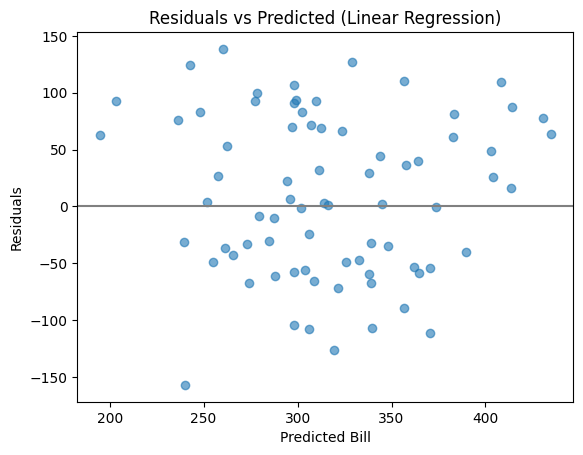


=== Decision Tree Regression ===
RMSE: 91.06

=== Random Forest Regression ===
RMSE: 79.86

=== XGBoost Regression ===
RMSE: 93.38

===== MODEL COMPARISON =====
Linear Regression: 71.07
Decision Tree: 91.06
Random Forest: 79.86
XGBoost: 93.38

Saved new file with predictions → billing_churn_with_predictions.csv

Preview:
   customer_id  usage_gb  call_mins  complaints plan_type   region  \
0         1001     11.65      427.0           2   Prepaid  Chennai   
1         1002      8.75      514.0           0   Prepaid  Kolkata   
2         1003      8.36      234.0           1   Prepaid   Mumbai   
3         1004      8.36      432.0           0   Prepaid  Chennai   
4         1005     17.95      477.0           0   Prepaid    Delhi   

   monthly_bill churn  predicted_monthly_bill  
0        337.36    No                  396.07  
1        305.34    No                  326.31  
2        245.95    No                  295.10  
3        248.32    No                  305.08  
4        374.76

In [1]:
# =========================================
# 1) Setup
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor

np.random.seed(42)


# =========================================
# 2) Create Dummy Dataset
# =========================================

n = 250

df = pd.DataFrame({
    "customer_id": range(1001, 1001+n),
    "usage_gb": np.random.gamma(5,2,n).round(2),
    "call_mins": np.random.normal(350,120,n).clip(50,900).round(0),
    "complaints": np.random.poisson(0.6,n),
    "plan_type": np.random.choice(["Prepaid","Postpaid"],n,p=[0.6,0.4]),
    "region": np.random.choice(["Delhi","Mumbai","Chennai","Kolkata"],n)
})

base = 99 + 8*df["usage_gb"] + 0.2*df["call_mins"] + 30*df["complaints"]
base += np.where(df["plan_type"]=="Postpaid",120,0)

df["monthly_bill"] = (base + np.random.normal(0,40,n)).round(2)

logit = -2.2 + 0.35*df["complaints"] - 0.002*(df["monthly_bill"]-200) + 0.15*(df["usage_gb"]<5)
prob = 1/(1+np.exp(-logit))

df["churn"] = np.where(np.random.rand(n)<prob,"Yes","No")

df.to_csv("billing_churn.csv",index=False)

print("Saved billing_churn.csv with shape:",df.shape)
print(df.head())


# =========================================
# 3) Load Dataset
# =========================================

df = pd.read_csv("billing_churn.csv")

print(df.shape)
print(df.head())


# =========================================
# 4) Basic Preprocessing
# =========================================

num_features = ["usage_gb","call_mins","complaints"]

X = df[num_features]

y_reg = df["monthly_bill"]


# =========================================
# 5) Train Test Split
# =========================================

X_train,X_test,y_train,y_test = train_test_split(
    X,y_reg,test_size=0.3,random_state=42
)


# =========================================
# 6A) Linear Regression
# =========================================

reg = LinearRegression()

reg.fit(X_train,y_train)

y_pred_lr = reg.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test,y_pred_lr))

print("\n=== Linear Regression ===")

print("Coefficients:",dict(zip(num_features,reg.coef_.round(3))))

print("Intercept:",round(reg.intercept_,2))

print("RMSE:",round(rmse_lr,2))


# Residual Plot

resid = y_test - y_pred_lr

plt.scatter(y_pred_lr,resid,alpha=0.6)

plt.axhline(0,color='gray')

plt.xlabel("Predicted Bill")

plt.ylabel("Residuals")

plt.title("Residuals vs Predicted (Linear Regression)")

plt.show()


# =========================================
# 6B) Decision Tree Regression
# =========================================

tree = DecisionTreeRegressor(max_depth=5,random_state=42)

tree.fit(X_train,y_train)

y_pred_tree = tree.predict(X_test)

rmse_tree = np.sqrt(mean_squared_error(y_test,y_pred_tree))

print("\n=== Decision Tree Regression ===")

print("RMSE:",round(rmse_tree,2))


# =========================================
# 6C) Random Forest Regression
# =========================================

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=6,
    random_state=42
)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test,y_pred_rf))

print("\n=== Random Forest Regression ===")

print("RMSE:",round(rmse_rf,2))


# =========================================
# 6D) XGBoost Regression
# =========================================

xgb = XGBRegressor(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train,y_train)

y_pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test,y_pred_xgb))

print("\n=== XGBoost Regression ===")

print("RMSE:",round(rmse_xgb,2))


# =========================================
# 7) Model Comparison
# =========================================

results = {
"Linear Regression": rmse_lr,
"Decision Tree": rmse_tree,
"Random Forest": rmse_rf,
"XGBoost": rmse_xgb
}

print("\n===== MODEL COMPARISON =====")

for model,score in results.items():
    print(f"{model}: {score:.2f}")


# =========================================
# 8) Save Predictions
# =========================================

X_all = df[num_features]

df["predicted_monthly_bill"] = reg.predict(X_all).round(2)

output_path = "billing_churn_with_predictions.csv"

df.to_csv(output_path,index=False)

print("\nSaved new file with predictions →",output_path)

print("\nPreview:")

print(df.head())